# Các phương pháp tối ưu cho mạng Neuron

Khi huấn luyện mạng neuron, mục tiêu là tìm bộ trọng số $\theta$ làm **cực tiểu hóa hàm mất mát** $L(\theta)$. Các *optimizer* (bộ tối ưu) khác nhau ở cách dùng gradient $\nabla_\theta L$ để cập nhật trọng số sau mỗi bước.

Notebook này trình bày **3 phương pháp tối ưu phổ biến nhất**:

1. **SGD** (Stochastic Gradient Descent) — nền tảng của mọi phương pháp
2. **SGD + Momentum** — thêm "quán tính" để đi nhanh và mượt hơn
3. **Adam** — tự điều chỉnh learning rate cho từng tham số

Cuối notebook là **ví dụ cụ thể**: cài đặt cả 3 optimizer từ đầu bằng NumPy và so sánh chúng khi huấn luyện một mạng neuron nhỏ trên bài toán phân loại 2 lớp.

## 1. SGD — Stochastic Gradient Descent

Ý tưởng: đi ngược hướng gradient (hướng dốc xuống nhanh nhất) một bước nhỏ có độ dài tỉ lệ với **learning rate** $\eta$:

$$\theta_{t+1} = \theta_t - \eta \, \nabla_\theta L(\theta_t)$$

Chữ **"Stochastic"** (ngẫu nhiên) nghĩa là thay vì tính gradient trên *toàn bộ* dữ liệu (rất chậm), ta chỉ tính trên một **mini-batch** (ví dụ 32 mẫu) được lấy ngẫu nhiên. Gradient vì thế hơi "nhiễu", nhưng mỗi bước cập nhật rẻ hơn rất nhiều và độ nhiễu này còn giúp thoát khỏi các điểm cực tiểu địa phương nông.

**Ưu điểm:** đơn giản, ít siêu tham số, được hiểu rõ về mặt lý thuyết.

**Nhược điểm:**
- Rất nhạy với việc chọn $\eta$: quá lớn thì phân kỳ, quá nhỏ thì hội tụ chậm.
- Dùng *cùng một* learning rate cho mọi tham số.
- Trong các "thung lũng hẹp" (hàm mất mát dốc theo chiều này nhưng thoải theo chiều kia), SGD dao động qua lại thay vì tiến thẳng về đích.

## 2. SGD + Momentum

Ý tưởng: mô phỏng **quán tính vật lý** — như hòn bi lăn xuống dốc, nó tích lũy vận tốc theo hướng đi ổn định và triệt tiêu các dao động qua lại. Ta duy trì thêm một biến **vận tốc** $v$ là trung bình động của các gradient trước đó:

$$v_{t+1} = \beta \, v_t + \nabla_\theta L(\theta_t)$$
$$\theta_{t+1} = \theta_t - \eta \, v_{t+1}$$

với $\beta$ (thường $= 0.9$) là hệ số momentum — quyết định giữ lại bao nhiêu vận tốc cũ.

**Trực giác:** nếu gradient liên tục chỉ về cùng một hướng qua nhiều bước, vận tốc được cộng dồn → đi nhanh hơn. Nếu gradient đổi dấu liên tục (dao động), các thành phần ngược chiều tự triệt tiêu nhau → quỹ đạo mượt hơn.

**Ưu điểm:** hội tụ nhanh hơn SGD thuần, giảm dao động, vượt qua được các vùng phẳng và cực tiểu địa phương nông.

**Nhược điểm:** thêm một siêu tham số $\beta$ phải chọn; vẫn dùng chung một learning rate cho mọi tham số.

## 3. Adam — Adaptive Moment Estimation

Adam kết hợp **hai ý tưởng**: momentum (moment bậc 1) và **learning rate thích nghi cho từng tham số** (moment bậc 2, kế thừa từ RMSProp). Với gradient $g_t = \nabla_\theta L(\theta_t)$:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\, g_t \qquad \text{(trung bình động của gradient)}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2)\, g_t^2 \qquad \text{(trung bình động của gradient bình phương)}$$

Vì $m_0 = v_0 = 0$ nên ở các bước đầu hai ước lượng này bị lệch về 0, cần **hiệu chỉnh độ lệch** (bias correction):

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

Cập nhật trọng số:

$$\theta_{t+1} = \theta_t - \eta \, \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

**Trực giác:** tham số nào có gradient *lớn và biến động mạnh* (căn $\hat{v}_t$ lớn) thì bước đi bị thu nhỏ lại; tham số nào có gradient *nhỏ nhưng ổn định* thì được bước dài hơn. Mỗi tham số có một learning rate hiệu dụng riêng.

Giá trị mặc định gần như luôn dùng được: $\eta = 0.001$, $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$.

**Ưu điểm:** hội tụ nhanh, ít phải tinh chỉnh learning rate, hoạt động tốt với gradient thưa — là lựa chọn mặc định trong thực tế.

**Nhược điểm:** đôi khi tổng quát hóa (generalize) kém hơn SGD+Momentum được tinh chỉnh kỹ; tốn bộ nhớ hơn (lưu cả $m$ và $v$ cho mỗi tham số).

### Bảng so sánh nhanh

| | SGD | Momentum | Adam |
|---|---|---|---|
| Trạng thái lưu thêm | không | $v$ | $m$ và $v$ |
| Learning rate theo tham số | không | không | **có** |
| Tốc độ hội tụ | chậm | khá | **nhanh** |
| Độ nhạy với $\eta$ | cao | trung bình | **thấp** |
| Khi nào dùng | baseline, nghiên cứu | computer vision (tinh chỉnh kỹ) | mặc định cho hầu hết bài toán |

---
## Ví dụ cụ thể: so sánh 3 optimizer trên bài toán phân loại "two moons"

Ta sẽ:
1. Tạo bộ dữ liệu 2 chiều hình hai vầng trăng đan vào nhau (không phân tách tuyến tính được).
2. Xây một mạng neuron nhỏ **2 → 16 → 1** (ẩn dùng $\tanh$, đầu ra dùng sigmoid) bằng NumPy thuần, tự viết forward và backward.
3. Cài đặt cả 3 optimizer đúng theo công thức ở trên.
4. Huấn luyện cùng một mạng (cùng trọng số khởi tạo) với từng optimizer và so sánh đường loss + ranh giới phân lớp.

### Bước 1 — Tạo dữ liệu

X: (400, 2) | y: (400, 1)


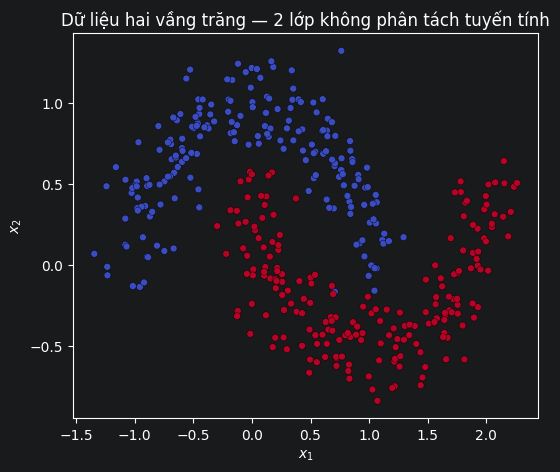

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def make_moons(n_samples=400, noise=0.15, seed=42):
    """Tạo dữ liệu hai vầng trăng đan nhau (phiên bản NumPy thuần)."""
    rng = np.random.default_rng(seed)
    n = n_samples // 2
    t = np.linspace(0, np.pi, n)
    moon_tren = np.c_[np.cos(t), np.sin(t)]
    moon_duoi = np.c_[1 - np.cos(t), 0.5 - np.sin(t)]
    X = np.vstack([moon_tren, moon_duoi]) + rng.normal(0, noise, (n_samples, 2))
    y = np.hstack([np.zeros(n), np.ones(n)]).reshape(-1, 1)
    return X, y


X, y = make_moons()
print('X:', X.shape, '| y:', y.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='coolwarm', s=25, edgecolors='k', linewidths=0.3)
plt.title('Dữ liệu hai vầng trăng — 2 lớp không phân tách tuyến tính')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

### Bước 2 — Mạng neuron 2 → 16 → 1 bằng NumPy

- **Forward:** $a_1 = \tanh(XW_1 + b_1)$, $\hat{y} = \sigma(a_1 W_2 + b_2)$
- **Loss:** binary cross-entropy $L = -\frac{1}{m}\sum \big[y\log\hat{y} + (1-y)\log(1-\hat{y})\big]$
- **Backward:** tính gradient của loss theo từng trọng số bằng quy tắc chuỗi (backpropagation).

Lưu ý: mọi optimizer đều nhận **cùng một dict `grads`** từ hàm `backward` — chúng chỉ khác nhau ở cách *dùng* gradient để cập nhật.

In [2]:
def init_params(seed=0):
    """Khởi tạo trọng số. Dùng cùng seed để mọi optimizer xuất phát từ cùng một điểm."""
    rng = np.random.default_rng(seed)
    return {
        'W1': rng.normal(0, 0.5, (2, 16)),
        'b1': np.zeros((1, 16)),
        'W2': rng.normal(0, 0.5, (16, 1)),
        'b2': np.zeros((1, 1)),
    }


def forward(params, X):
    z1 = X @ params['W1'] + params['b1']
    a1 = np.tanh(z1)
    z2 = a1 @ params['W2'] + params['b2']
    y_hat = 1 / (1 + np.exp(-z2))          # sigmoid
    cache = (X, a1, y_hat)
    return y_hat, cache


def bce_loss(y_hat, y):
    eps = 1e-12                             # tránh log(0)
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))


def backward(params, cache, y):
    """Backpropagation — trả về dict gradient cùng khóa với params."""
    X, a1, y_hat = cache
    m = X.shape[0]
    # Đạo hàm của BCE qua sigmoid rút gọn rất đẹp: dL/dz2 = (y_hat - y) / m
    dz2 = (y_hat - y) / m
    grads = {
        'W2': a1.T @ dz2,
        'b2': dz2.sum(axis=0, keepdims=True),
    }
    da1 = dz2 @ params['W2'].T
    dz1 = da1 * (1 - a1 ** 2)               # đạo hàm của tanh: 1 - tanh^2
    grads['W1'] = X.T @ dz1
    grads['b1'] = dz1.sum(axis=0, keepdims=True)
    return grads

### Bước 3 — Cài đặt 3 optimizer

Mỗi optimizer là một class có phương thức `step(params, grads)` cập nhật trọng số tại chỗ — đúng theo công thức toán ở phần lý thuyết.

In [3]:
class SGD:
    """theta = theta - lr * grad"""

    def __init__(self, lr=0.1):
        self.lr = lr

    def step(self, params, grads):
        for k in params:
            params[k] -= self.lr * grads[k]


class Momentum:
    """v = beta*v + grad ;  theta = theta - lr * v"""

    def __init__(self, lr=0.1, beta=0.9):
        self.lr, self.beta = lr, beta
        self.v = None

    def step(self, params, grads):
        if self.v is None:
            self.v = {k: np.zeros_like(p) for k, p in params.items()}
        for k in params:
            self.v[k] = self.beta * self.v[k] + grads[k]
            params[k] -= self.lr * self.v[k]


class Adam:
    """Momentum (m) + learning rate thích nghi (v) + bias correction."""

    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m, self.v, self.t = None, None, 0

    def step(self, params, grads):
        if self.m is None:
            self.m = {k: np.zeros_like(p) for k, p in params.items()}
            self.v = {k: np.zeros_like(p) for k, p in params.items()}
        self.t += 1
        for k in params:
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)   # hiệu chỉnh độ lệch
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

### Bước 4 — Huấn luyện và so sánh

Cả 3 optimizer xuất phát từ **cùng một bộ trọng số khởi tạo** và dùng cùng thứ tự mini-batch, nên khác biệt trên đồ thị hoàn toàn do thuật toán cập nhật.

SGD (lr=0.1)           loss cuối = 0.1018 | accuracy = 96.5%
Momentum (lr=0.1)      loss cuối = 0.0167 | accuracy = 99.5%
Adam (lr=0.01)         loss cuối = 0.0306 | accuracy = 99.5%


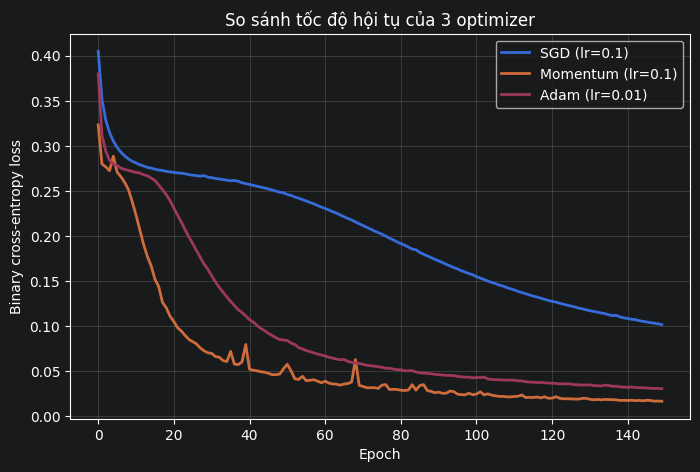

In [4]:
def train(optimizer, X, y, epochs=150, batch_size=32, seed=0):
    params = init_params(seed)
    rng = np.random.default_rng(seed)
    losses = []
    n = X.shape[0]
    for epoch in range(epochs):
        idx = rng.permutation(n)            # xáo trộn dữ liệu mỗi epoch
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            y_hat, cache = forward(params, X[batch])
            grads = backward(params, cache, y[batch])
            optimizer.step(params, grads)
        y_hat_full, _ = forward(params, X)  # loss trên toàn bộ dữ liệu sau mỗi epoch
        losses.append(bce_loss(y_hat_full, y))
    return params, losses


optimizers = {
    'SGD (lr=0.1)':        SGD(lr=0.1),
    'Momentum (lr=0.1)':   Momentum(lr=0.1, beta=0.9),
    'Adam (lr=0.01)':      Adam(lr=0.01),
}

results = {}
for name, opt in optimizers.items():
    params, losses = train(opt, X, y)
    y_hat, _ = forward(params, X)
    acc = np.mean((y_hat > 0.5) == y)
    results[name] = {'params': params, 'losses': losses, 'acc': acc}
    print(f'{name:<22} loss cuối = {losses[-1]:.4f} | accuracy = {acc:.1%}')

plt.figure(figsize=(8, 5))
for name, r in results.items():
    plt.plot(r['losses'], label=name, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy loss')
plt.title('So sánh tốc độ hội tụ của 3 optimizer')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Bước 5 — Trực quan hóa ranh giới phân lớp

Vẽ vùng quyết định mà mỗi mạng đã học được — màu nền thể hiện xác suất dự đoán cho từng điểm trong mặt phẳng.

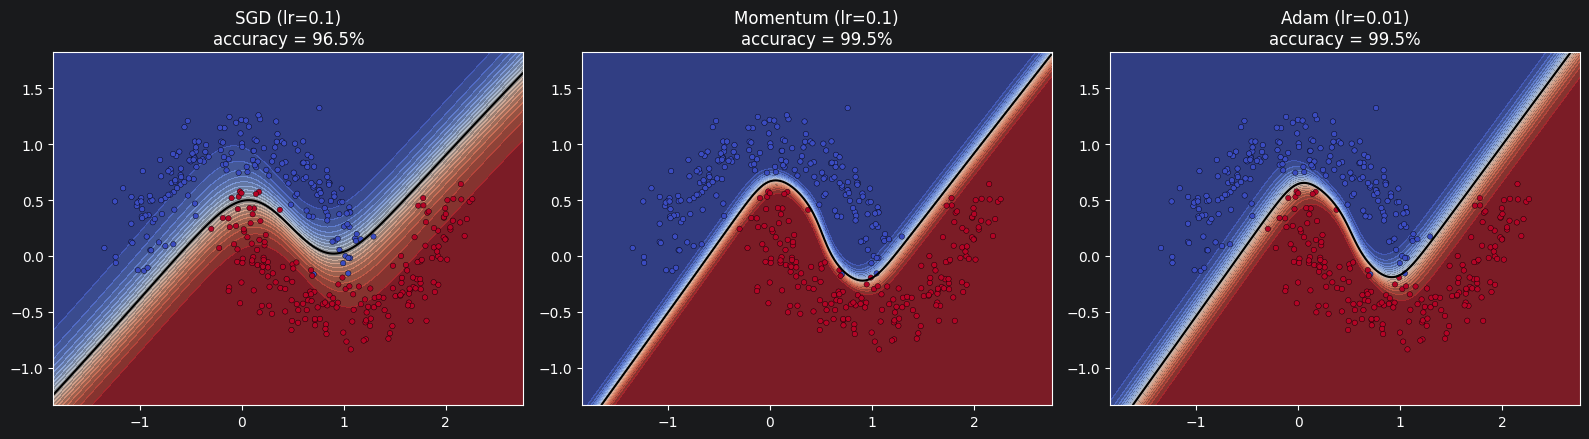

In [5]:
def plot_decision_boundary(ax, params, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs, _ = forward(params, grid)
    probs = probs.reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=20, cmap='coolwarm', alpha=0.6)
    ax.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='coolwarm', s=15,
               edgecolors='k', linewidths=0.3)
    ax.set_title(title)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, r) in zip(axes, results.items()):
    plot_decision_boundary(ax, r['params'], X, y,
                           f"{name}\naccuracy = {r['acc']:.1%}")
plt.tight_layout()
plt.show()

## Nhận xét và kết luận

Từ đồ thị loss và ranh giới phân lớp, bạn sẽ thấy:

- **SGD** hội tụ chậm nhất — đường loss đi xuống từ từ và còn dao động do gradient mini-batch nhiễu.
- **Momentum** giảm loss nhanh hơn rõ rệt nhờ tích lũy vận tốc theo hướng ổn định.
- **Adam** thường xuống nhanh nhất ngay từ những epoch đầu dù dùng learning rate nhỏ hơn 10 lần (0.01 so với 0.1) — đó chính là sức mạnh của việc tự điều chỉnh bước đi cho từng tham số.

**Lời khuyên thực tế khi mới bắt đầu:** cứ dùng **Adam với lr = 0.001 hoặc 0.01** làm mặc định. Khi cần vắt kiệt hiệu năng (ví dụ trong computer vision), thử SGD + Momentum kết hợp với *learning rate schedule* (giảm dần $\eta$ theo thời gian).

### Bài tập tự luyện

1. Tăng learning rate của SGD lên 1.0 — chuyện gì xảy ra với đường loss?
2. Đặt `beta=0.99` cho Momentum — quỹ đạo loss thay đổi thế nào? Vì sao?
3. Tự cài thêm **RMSProp** (chính là Adam nhưng bỏ moment bậc 1 và bias correction): $v_t = \beta v_{t-1} + (1-\beta)g_t^2$, $\theta_{t+1} = \theta_t - \eta\, g_t / (\sqrt{v_t} + \epsilon)$ — rồi thêm vào phần so sánh.
4. Tắt bias correction trong Adam (dùng thẳng $m_t, v_t$) và quan sát các epoch đầu tiên.